In [1]:
import numpy as np
import glob,os
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.mpl.ticker as cticker
from cartopy.feature.nightshade import Nightshade
from datetime import datetime, date,timedelta
import xarray as xr
import matplotlib.gridspec as gridspec
import scipy.io as sio
import imageio.v2 as imageio
import re
from cartopy.util import add_cyclic_point
from collections import defaultdict
from cmcrameri import cm
from scipy.interpolate import interp1d
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter,LongitudeLocator,LatitudeLocator
import time
import matplotlib as mpl
from cartopy.feature.nightshade import Nightshade
import matplotlib.dates as mdates
import matplotlib.image as mpimg
import seaborn as sns


In [2]:
def doy_to_month_day(year, doy):
    # Create a date object for the given year and DOY
    date = datetime(year, 1, 1) + timedelta(days=doy - 1)
    
    # Extract the month and day
    month = date.month
    day = date.day
    
    return month, day

def decimal_hours_to_hms(hh1):
    # Get whole hours
    hh = int(hh1)
    
    # Get minutes from the fractional part
    mm, remainder = divmod((hh1 - hh) * 3600, 60)
    mm = int(mm)
    
    # Get seconds from the remainder and round to nearest integer
    ss = round(remainder)
    
    # Handle the case where seconds round to 60
    if ss == 60:
        ss = 0
        mm += 1
        if mm == 60:
            mm = 0
            hh += 1
    
    return hh, mm, ss


def parse_map(tecmap, exponent = -1):
    tecmap = re.split('.*END OF TEC MAP', tecmap)[0]
    return np.stack([np.fromstring(l, sep=' ') for l in re.split('.*LAT/LON1/LON2/DLON/H\\n',tecmap)[1:]])*10**exponent
    
def get_tecmaps(filename):
    with open(filename) as f:
        ionex = f.read()
        return [parse_map(t) for t in ionex.split('START OF TEC MAP')[1:]]
    


In [3]:
yr=2024
yr1=yr%100
dstfile='kp_dst.txt'
dst_ut=np.arange(24*4)

with open(dstfile,'r') as f:text=f.readlines()
dstdata=np.zeros([len(text),5])
for i in range(len(text)):
    data=np.array(text[i].split())
    dstdata[i,0]=int(data[0])
    dstdata[i,1]=int(data[1])
    dstdata[i,2]=int(data[2])
    dstdata[i,3]=int(data[3])/10#kp
    dstdata[i,4]=int(data[4])#dst


/tmp/ipykernel_1655714/1520722566.py:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


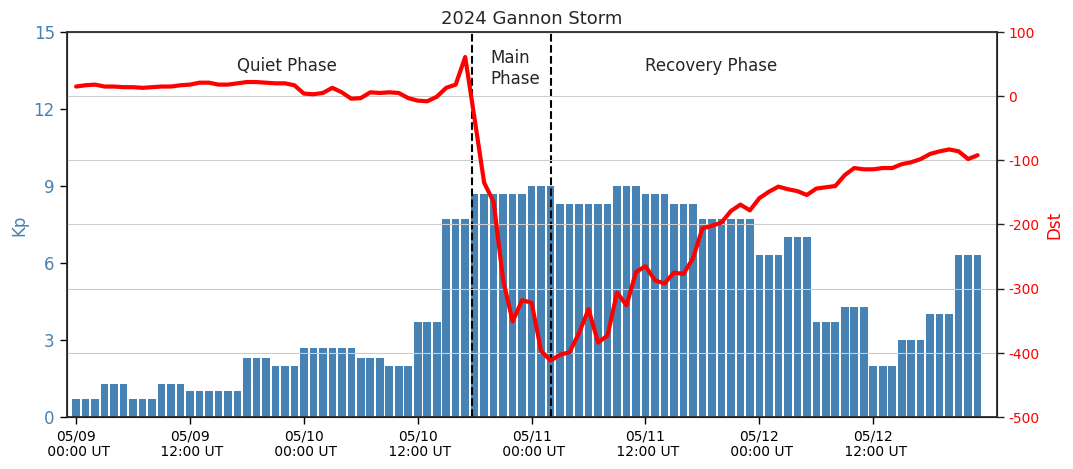

In [4]:

dst_ut=np.arange(24*4)

# Example data
#dst_ut = np.arange(0, 4 * 24, 3)  # Every 3 hours for 4 days
#dstdata = np.random.rand(len(dst_ut), 5) * 10  # Dummy data
main_ph=26+24
quiet_ph=24+17+40/60
fig, ax3 = plt.subplots(dpi=100)
plt.style.use('seaborn-white')

start_date = datetime(2024, 5, 9)
dates1 = [start_date + timedelta(hours=int(h)) for h in dst_ut]

fig.set_size_inches(12, 5)
ax3.bar(dst_ut, dstdata[:, 3], color='steelblue')
ax3.set(ylim=(0, 15))
ax3.set(xlim=(-1, 24 * 4 + 1))
ax3.plot([main_ph,main_ph],[0, 15],'--k','linewidth',3)
ax3.plot([quiet_ph,quiet_ph],[0, 15],'--k','linewidth',3)
ax3.text(quiet_ph+2,13,'Main\nPhase',fontsize=12)
ax3.text(main_ph+10,13.5,'Recovery Phase',fontsize=12)
ax3.text(17,13.5,'Quiet Phase',fontsize=12)

ax3.set_yticks(np.arange(0, 16, 3))
ax3.set_yticklabels(np.arange(0, 16, 3), color='steelblue', fontsize=12)
ax3.set_ylabel('Kp', color='steelblue',fontsize=12)

#ax3.set_xlabel('UT (hr)')
ax2 = ax3.twinx()
ax2.plot(dst_ut, dstdata[:, 4], '-r', linewidth=3)
ax2.set_xticks(np.arange(0, 4 * 24, 12))  # Tick every 12 hours

# Set x-tick labels with both date and hour
xtick_labels = [d.strftime('%m/%d\n %H:%M UT') for d in dates1[::12]]
ax2.set_xticklabels(xtick_labels, rotation=60, ha='right')
ax3.tick_params(axis='x', which='both', length=5, width=1)  # Adjust tick length and width if needed
ax3.tick_params(axis='y', which='both', length=5, width=1)  # Adjust tick length and width if needed
ax2.tick_params(axis='y', which='both', length=5, width=1)  # Adjust tick length and width if needed

ax2.set(ylim=(-500, 100))
ax2.grid(True)
ax2.set_yticks(np.arange(-500, 200, 100))
ax2.set_yticklabels(np.arange(-500, 200, 100), color='r')
ax2.set_ylabel('Dst', color='r',fontsize=12)
ax2.set_title('2024 Gannon Storm',fontsize=13)

plt.show()


In [5]:
yr=2024
yr1=yr%100
doy1=130
#model='GloTEC'

cmap1=plt.get_cmap('viridis',30)
cmap2=plt.get_cmap('coolwarm',30)
#cmap1=plt.get_cmap('hot',30)
cmap2=cm.roma_r
print(cm.__file__)

/home/mchou1/.local/lib/python3.10/site-packages/cmcrameri/cm.py


# Load TEC and TEC RMSE data


In [6]:
all_data = np.load('TEC_rmse_UTLAT_map.npz', allow_pickle=True)
#model_data = all_data['model_data'].item()
RMSE_UTLAT=all_data['RMSE_UTLAT'].item()
TEC_UTLAT=all_data['TEC_UTLAT'].item()
model_latidx=all_data['model_latidx']

# TEC RMSE maps  as a function of UT and latitude

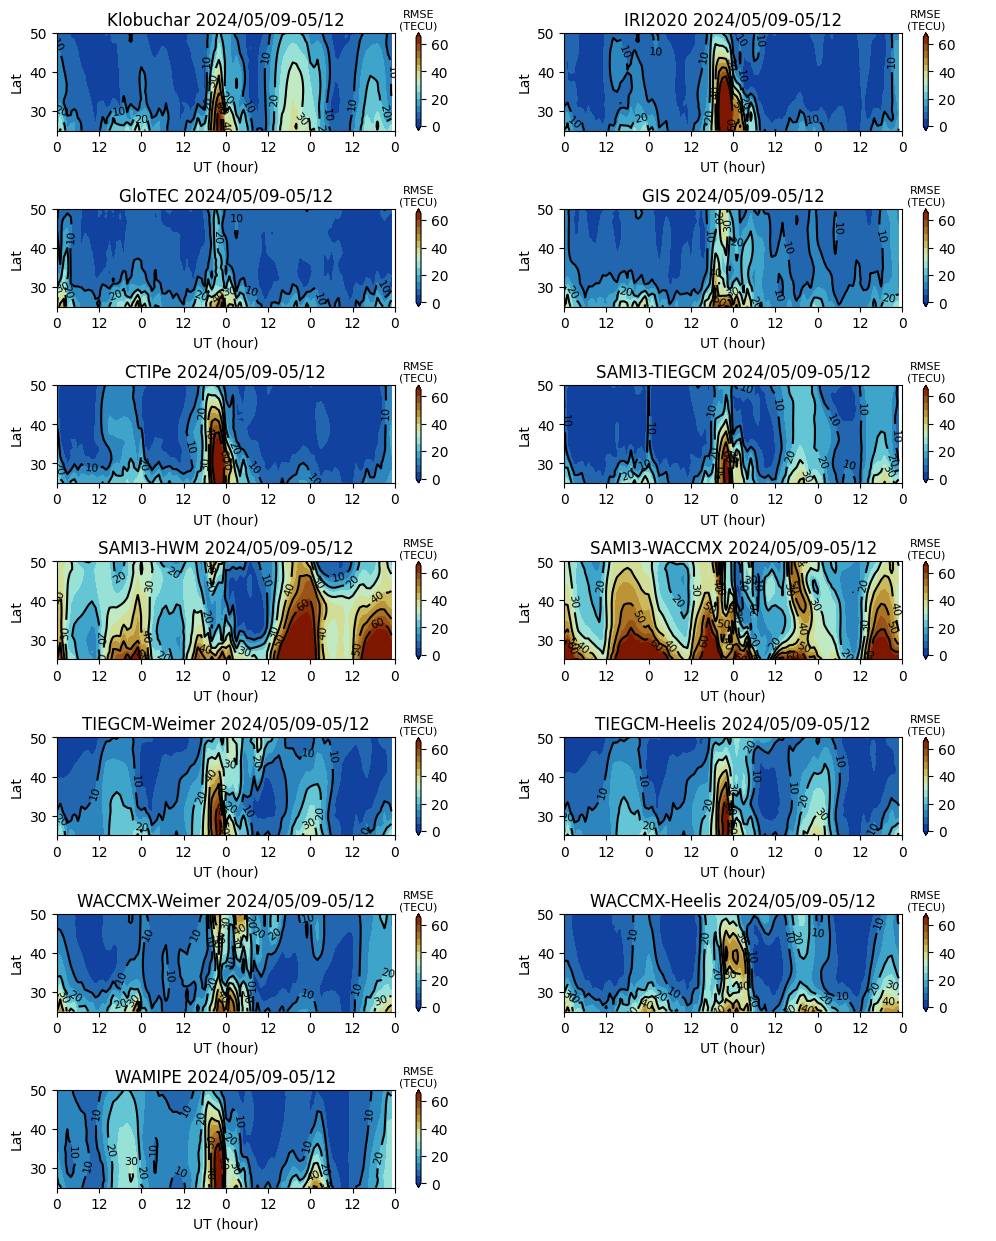

In [18]:
cmap2=cm.roma_r
#models=['Madrigal TEC','Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','TIEGCM-Heelis']
models=['Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WACCMX-Weimer','WACCMX-Heelis','WAMIPE']
plt.style.use('default')
            #gs=fig.add_gridspec(2,3)
fig,(axs)=plt.subplots(7,2,dpi=100)
fig.set_size_inches(12, 15)
plt.subplots_adjust(hspace = .8)
level=np.arange(0,70,5)
for model, ax in zip(models,axs.ravel()):
    #cntr1=ax.pcolor(np.arange(0,3*24,1),model_latidx,(TEC_UTLAT[model]-TEC_UTLAT['Madrigal TEC']),vmin=-20,vmax=20,cmap=cmap2);
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx, RMSE_UTLAT[model],levels=level,cmap=cmap2,extend='both');
    #ccc=ax.contour(x,y,err1,levels=[-50,-25, 0, 25, 50],colors='black')
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx, RMSE_UTLAT[model],levels=[ 0,10,20,30,40,50,60],colors='black');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')

    ax.set_title(f'{model} 2024/05/09-05/12') #75-125W
    clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(0,70,20))
    ax.set_xticks(np.arange(0,4*24+1,12))
    ax.set_xticklabels(np.mod(np.arange(0,4*24+1,12),24))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')
    clb.ax.set_title('RMSE\n(TECU)', fontsize=8)

axs.ravel()[-1].axis('off')
plt.show()

# TEC maps as a function of UT and latitude

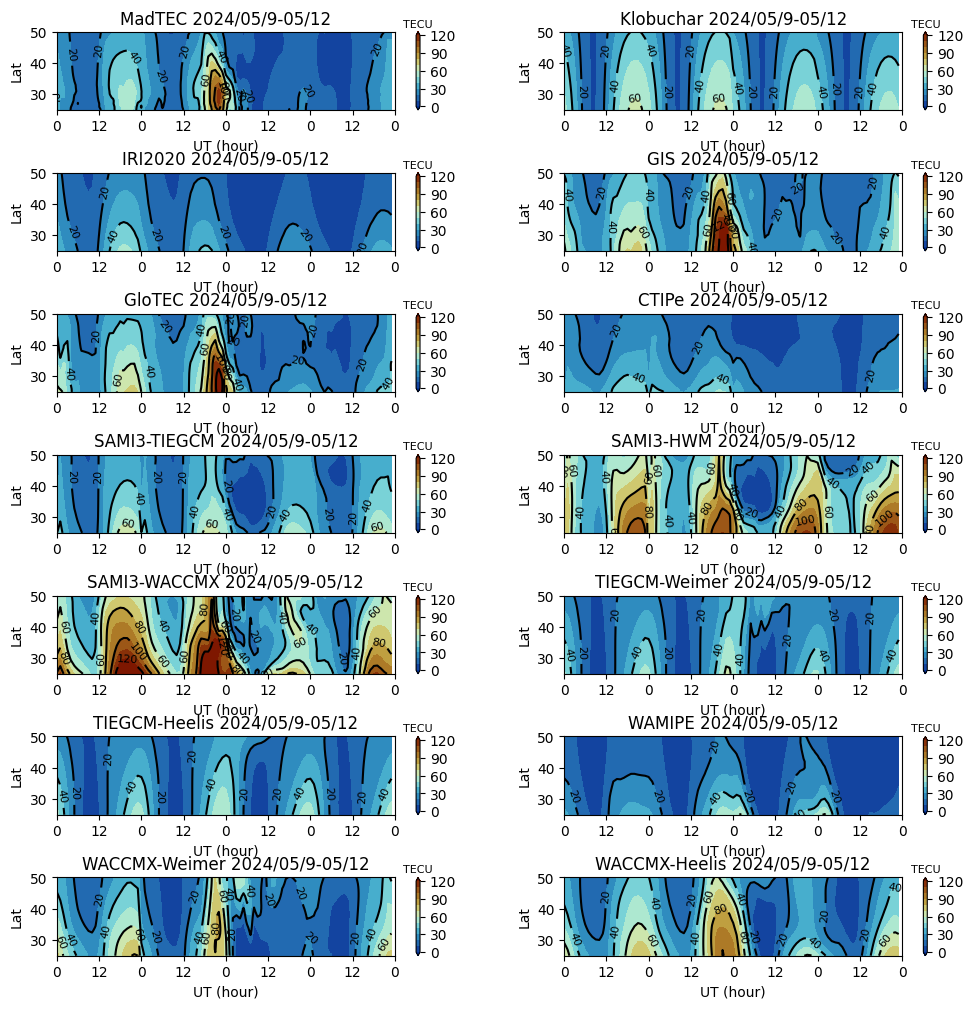

In [19]:
cmap2=cm.roma_r
#models=['Madrigal TEC','Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','TIEGCM-Heelis']
models=['MadTEC','Klobuchar','IRI2020','GIS','GloTEC','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Weimer','WACCMX-Heelis']
#models=['GNSSTEC','Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM',
#        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Weimer','WACCMX-Heelis']
plt.style.use('default')
            #gs=fig.add_gridspec(2,3)
fig,(axs)=plt.subplots(7,2,dpi=100)
fig.set_size_inches(12, 12)
plt.subplots_adjust(hspace = .8)
level=np.arange(0,130,10)
for model, ax in zip(models,axs.ravel()):
    #cntr1=ax.pcolor(np.arange(0,3*24,1),model_latidx,(TEC_UTLAT[model]-TEC_UTLAT['Madrigal TEC']),vmin=-20,vmax=20,cmap=cmap2);
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx, TEC_UTLAT[model],levels=level,cmap=cmap2,extend='both');
    #ccc=ax.contour(x,y,err1,levels=[-50,-25, 0, 25, 50],colors='black')
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx, TEC_UTLAT[model],levels=[ 0,20,40,60,80,100,120],colors='black');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')

    ax.set_title(f'{model} 2024/05/9-05/12') #75-125W
    clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(0,130,30))
    ax.set_xticks(np.arange(0,4*24+1,12))
    ax.set_xticklabels(np.mod(np.arange(0,4*24+1,12),24))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')
    clb.ax.set_title('TECU', fontsize=8)

#axs.ravel()[0].axis('off')
plt.show()

# load GNSS positioning error data

In [20]:
data=np.load(f'ERROR_UTLAT_map_75125W_60min.npz',allow_pickle=True)


# 3D error maps as a function of UT and LAT

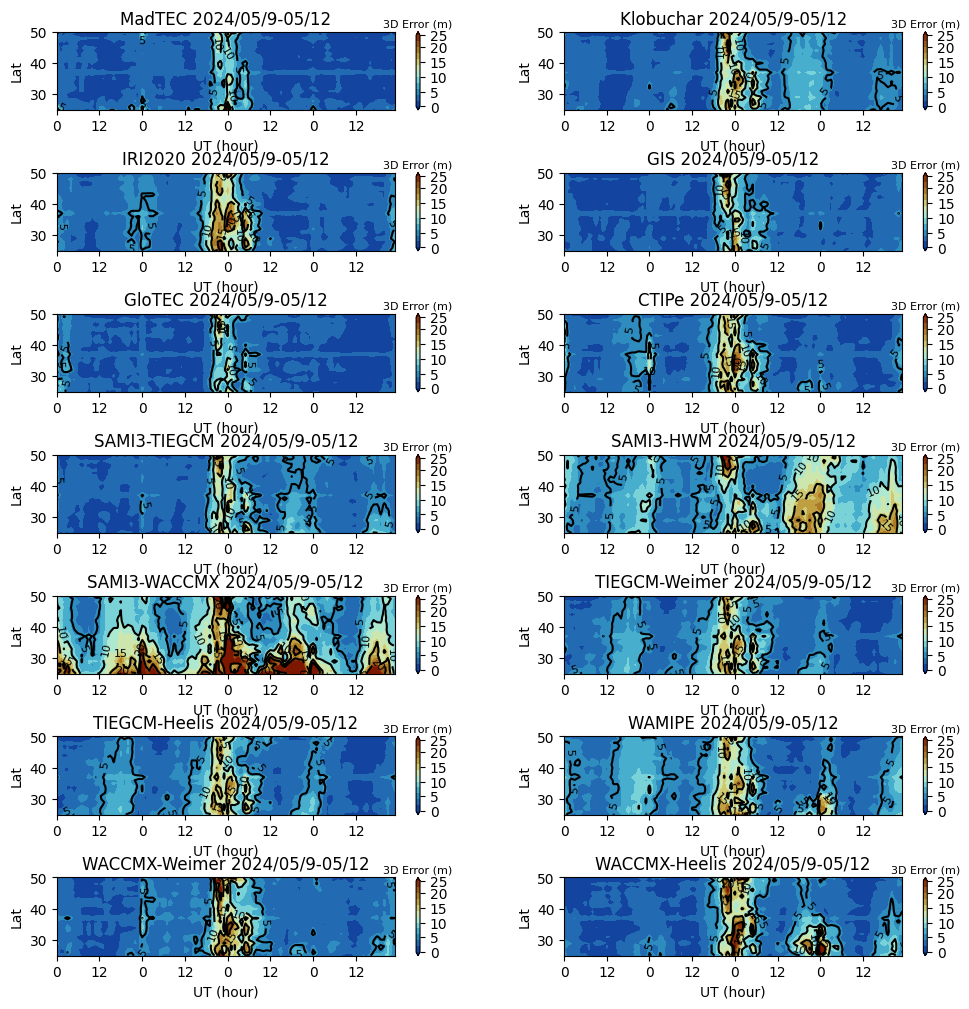

In [21]:
ERROR_UTLAT1=data['ERROR_3D_UTLAT'].item()

cmap2=cm.roma_r
model_latidx=np.arange(25,51,1)

plt.style.use('default')
fig,(axs)=plt.subplots(7,2,dpi=100)
fig.set_size_inches(12, 12)
plt.subplots_adjust(hspace = .8)
level=np.arange(0,25,2)
for model, ax in zip(models,axs.ravel()):
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=level,cmap=cmap2, extend='both');
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=[0,5,10,15,20],colors='black');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')

    #if model=='SAMI3-HWM':model='SAMI3'
    ax.set_title(f'{model} 2024/05/9-05/12')
    clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(0,26,5))
    ax.set_xticks(np.arange(0,4*24,12))
    ax.set_xticklabels(np.mod(np.arange(0,(4*24),12),24).astype(int))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')
    clb.ax.set_title('3D Error (m)', fontsize=8)
    #ax.set_xlim(100, 200)
#axs.ravel()[0].axis('off')
plt.show()

# 2D error maps as a function of UT and LAT

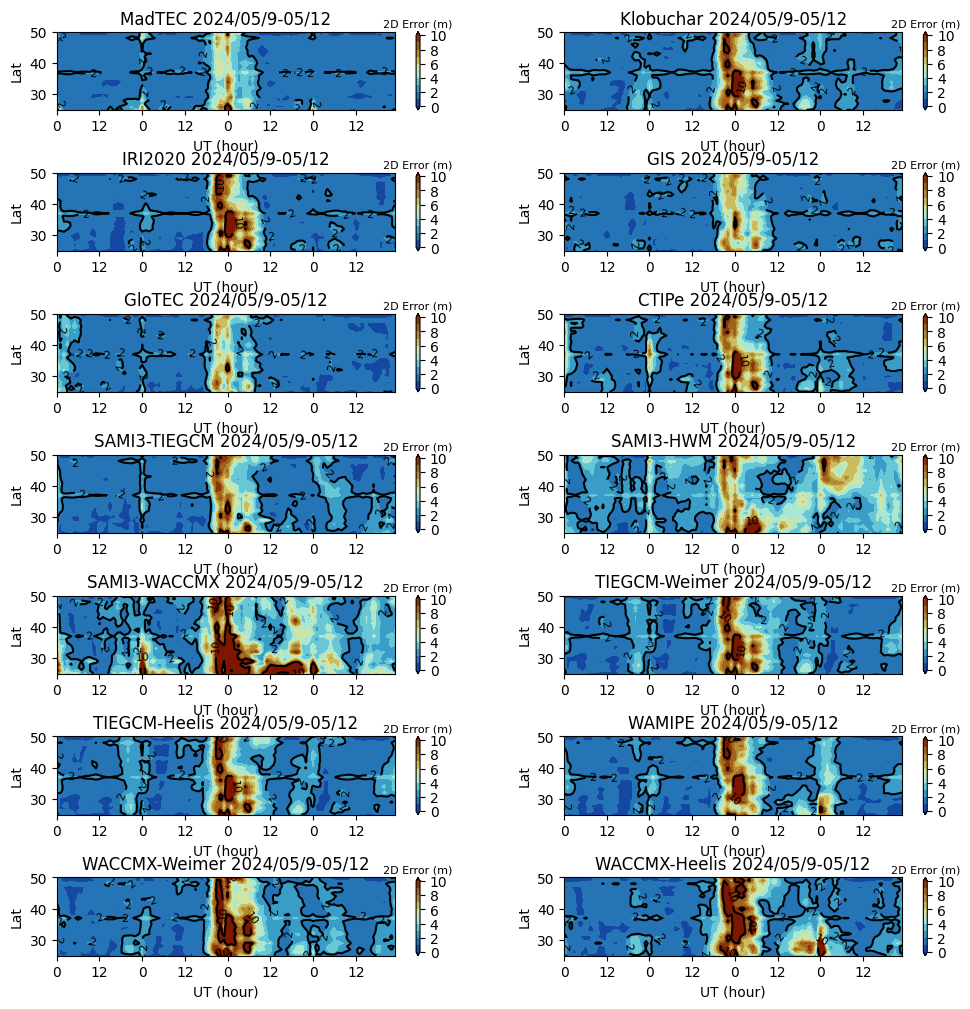

In [22]:
ERROR_UTLAT1=data['ERROR_2D_UTLAT'].item()
#models = ['Klobuchar' ,'IRI2020', 'GloTEC', 'GIS', 'CTIPe', 'SAMI3-TIEGCM', 'SAMI3-HWM', 'TIEGCM-Heelis']

cmap2=cm.roma_r
model_latidx=np.arange(25,51,1)

plt.style.use('default')
fig,(axs)=plt.subplots(7,2,dpi=100)
fig.set_size_inches(12, 12)
plt.subplots_adjust(hspace = .8)
level=np.arange(0,11,1)
for model, ax in zip(models,axs.ravel()):
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=level,cmap=cmap2, extend='both');
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=[0,2,10],colors='black');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')

    #if model=='SAMI3-HWM':model='SAMI3'
    ax.set_title(f'{model} 2024/05/9-05/12')
    clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(0,12,2))
    ax.set_xticks(np.arange(0,4*24,12))
    ax.set_xticklabels(np.mod(np.arange(0,(4*24),12),24).astype(int))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')
    clb.ax.set_title('2D Error (m)', fontsize=8)
    #ax.set_xlim(100, 200)
#axs.ravel()[-1].axis('off')
plt.show()

# Up (East or North) error maps as a function of UT and LAT

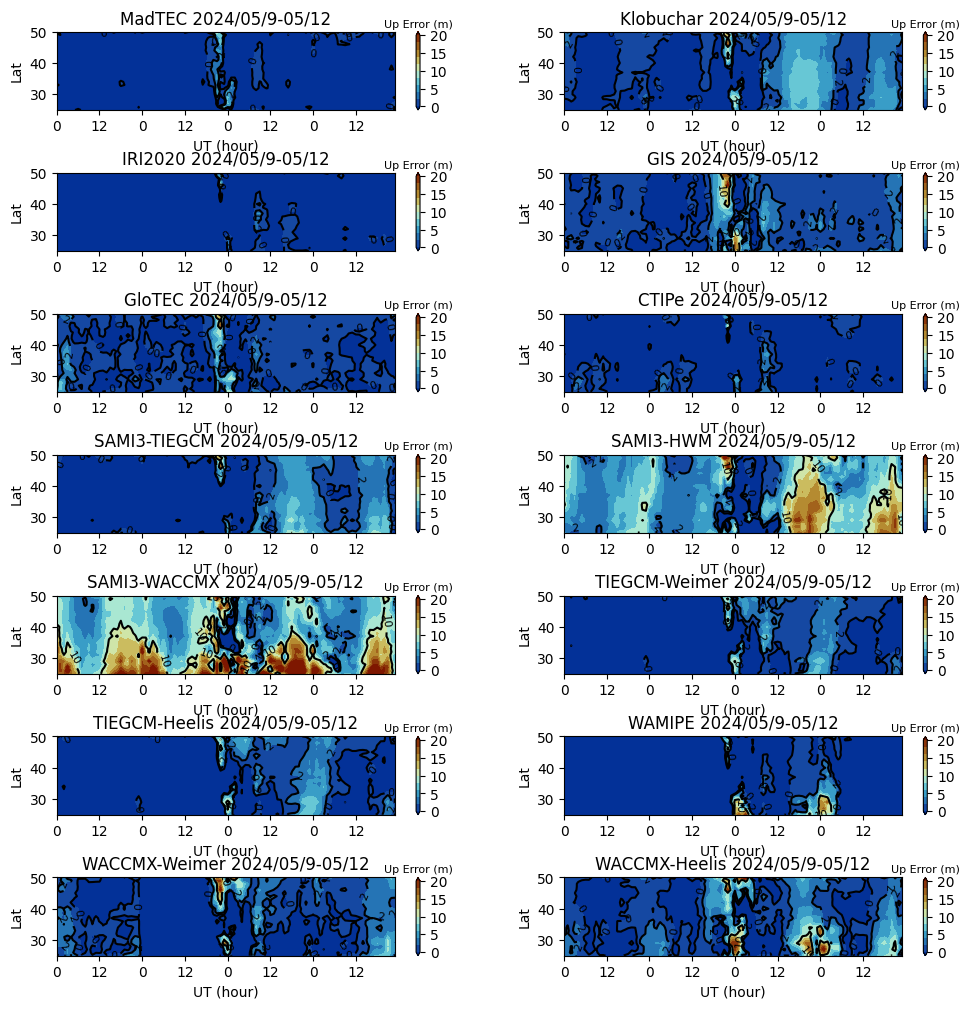

In [23]:
#ERROR_UTLAT1=data['ERROR_N_UTLAT'].item  # North error
#ERROR_UTLAT1=data['ERROR_E_UTLAT'].item() # East error
ERROR_UTLAT1=data['ERROR_U_UTLAT'].item() # Up error

cmap2=cm.roma_r
model_latidx=np.arange(25,51,1)

plt.style.use('default')
fig,(axs)=plt.subplots(7,2,dpi=100)
fig.set_size_inches(12, 12)
plt.subplots_adjust(hspace = .8)
level=np.arange(0,21,2)
for model, ax in zip(models,axs.ravel()):
    cntr1=ax.contourf(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=level,cmap=cmap2, extend='both');
    ccc=ax.contour(np.arange(0,4*24,1),model_latidx,ERROR_UTLAT1[model],levels=[0,2,10],colors='black');
    plt.clabel(ccc, inline = True, fontsize=8, fmt='%d', colors = 'black')

    #if model=='SAMI3-HWM':model='SAMI3'
    ax.set_title(f'{model} 2024/05/9-05/12')
    clb=fig.colorbar(cntr1,ax=ax,ticks=np.arange(0,21,5))
    ax.set_xticks(np.arange(0,4*24,12))
    ax.set_xticklabels(np.mod(np.arange(0,(4*24),12),24).astype(int))
    ax.set_ylabel('Lat')
    ax.set_xlabel('UT (hour)')
    clb.ax.set_title('Up Error (m)', fontsize=8)
    #ax.set_xlim(100, 200)
#axs.ravel()[-1].axis('off')
plt.show()



# calculate TEC error between models and observation

data=np.load(f'g_model_TEC.npz',allow_pickle=True)
model_data=data['model_data'].item()

lon1,lon2=-75,-125
models=['Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Weimer','WACCMX-Heelis']
model_latidx=np.arange(25,51,1)
#RMSE_UTLAT = {model: np.zeros([len(model_latidx),24*4]) for model in models}
#TEC_UTLAT = {model: np.zeros([len(model_latidx),24*4]) for model in models}
#TEC_UTLAT['GNSSTEC'] = np.zeros([len(model_latidx),24*4])
dt=1

obs_ut=model_data['MadTEC']['ut']
obs_lon=model_data['MadTEC']['lon']
obs_lat=model_data['MadTEC']['lat']
obs_TEC=model_data['MadTEC']['TEC'].reshape(4 * 145, 181, 361)
ut_time1=np.tile(obs_ut,(1,4))[0]

idx1=np.where(ut_time1==ut_time1[0])[0]
ut_time1[idx1[1]:idx1[2]]=ut_time1[idx1[1]:idx1[2]]+24
ut_time1[idx1[2]:idx1[3]]=ut_time1[idx1[2]:idx1[3]]+48
ut_time1[idx1[3]:]=ut_time1[idx1[3]:]+72

main_ph=26+24
quiet_ph=24+17+40/60
II1 = np.where(ut_time1<=quiet_ph)[0]
II2 =  np.where((ut_time1 > quiet_ph) & (ut_time1 <= main_ph) )[0]
II3 = np.where(ut_time1 > main_ph)[0]

TEC_rms_error=np.zeros([len(models),3])
TEC_mean_error=np.zeros([len(models),3])
TEC_std_error=np.zeros([len(models),3])

for modelidx,model in enumerate(models):
    model_ut=model_data[model]['ut']
    model_lon=model_data[model]['lon']
    model_lat=model_data[model]['lat']
    model_TEC=model_data[model]['TEC'].reshape(4 * 145, 181, 361)

    for idx1,inx in enumerate([II1,II2,II3]):
     
        J=np.where((model_lon <= lon1) & (model_lon > lon2))[0]
        K=np.where((model_lat<=50)&(model_lat>=25))[0]
        tec1 = model_TEC[np.ix_(inx, K, J)]
        tec2=obs_TEC[np.ix_(inx, K, J)]   
        var=(tec1-tec2)**2
        dtec=np.abs(tec1-tec2)
        TEC_rms_error[modelidx,idx1]=np.sqrt(np.nanmean(var.ravel()))
        TEC_mean_error[modelidx,idx1]=np.nanmean(dtec)
        TEC_std_error[modelidx,idx1]=np.nanstd(dtec)


# Calculate positioning error (mean, rmse, std)

model_latidx = np.arange(25, 50, 2)
lon0, lon01, lat0, lat01 = -125, -75, model_latidx[0], model_latidx[-1]

#models = ['Klobuchar' ,'IRI2020', 'GloTEC', 'GIS', 'CTIPe', 'SAMI3-TIEGCM', 'SAMI3-HWM', 'TIEGCM-Heelis']
#models=['Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM',
#        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Weimer','WACCMX-Heelis']

ut_time=np.arange(300/3600,300*287/3600,300/3600)

ut_time1=np.tile(ut_time,(1,4))[0]
idx1=np.where(ut_time1==ut_time1[0])[0]
ut_time1[idx1[1]:idx1[2]]=ut_time1[idx1[1]:idx1[2]]+24
ut_time1[idx1[2]:idx1[3]]=ut_time1[idx1[2]:idx1[3]]+48
ut_time1[idx1[3]:]=ut_time1[idx1[3]:]+72

main_ph=26+24
quiet_ph=24+17+40/60
II1 = ut_time1<=quiet_ph
II2 =  (ut_time1 > quiet_ph) & (ut_time1 <= main_ph) 
II3 = ut_time1 > main_ph

rms_error_3d=np.zeros([len(models),3])
mean_error_3d=np.zeros([len(models),3])
std_error_3d=np.zeros([len(models),3])
rms_error_2d=np.zeros([len(models),3])
mean_error_2d=np.zeros([len(models),3])
std_error_2d=np.zeros([len(models),3])
rms_error_u=np.zeros([len(models),3])
mean_error_u=np.zeros([len(models),3])
std_error_u=np.zeros([len(models),3])
for modidx,model in enumerate(models):
    dP,dE,dN,dU,LON,LAT=[],[],[],[],[],[]
    for doy in range(130, 134):
        cors_data = np.load(f'{model}_CORS_{yr}{doy:03d}_SPPP.npz', allow_pickle=True)
        sopac_data = np.load(f'{model}_SOPAC_{yr}{doy:03d}_SPPP.npz', allow_pickle=True)
        gnssdata=[cors_data['dP'],sopac_data['dP']]
        gnssdata1=[cors_data['LON'],sopac_data['LON']]
        gnssdata2=[cors_data['LAT'],sopac_data['LAT']]
        gnssdata4=[cors_data['dE'],sopac_data['dE']]
        gnssdata5=[cors_data['dN'],sopac_data['dN']]
        gnssdata6=[cors_data['dU'],sopac_data['dU']]
        #dp1 = np.hstack(cors_data['dP']+ sopac_data['dP'])
        dP.append(gnssdata)
        LON.append(gnssdata1)
        LAT.append(gnssdata2)
        dE.append(gnssdata4)
        dN.append(gnssdata5)
        dU.append(gnssdata6)

    dP = np.hstack(dP)   
    dE = np.hstack(dE)
    dN = np.hstack(dN)
    dU = np.hstack(dU)
    LON = np.hstack(LON)
    LAT = np.hstack(LAT)

    for idx1,inx in enumerate([II1,II2,II3]):
        dp1 = np.hstack(dP[0,inx] + dP[1,inx])#
        dn1 = np.hstack(dN[0,inx] + dN[1,inx])#
        de1 = np.hstack(dE[0,inx] + dE[1,inx])#
        du1 = np.hstack(dU[0,inx] + dU[1,inx])#
        d2d = np.sqrt(de1**2+dn1**2)
        lon1 = np.hstack(LON[0,inx] + LON[1,inx])#
        lat1 = np.hstack(LAT[0,inx] + LAT[1,inx])#
        II = (lon0 <= lon1) & (lon1 <= lon01) & (lat1 >= lat0) & (lat1 <= lat01) & (dp1<100) & (d2d<50) # remove outlier
        dp1,d2d1,du1, lon1, lat1 = dp1[II],d2d[II],du1[II],lon1[II], lat1[II]
        rms_error_3d[modidx,idx1]=np.sqrt(np.mean(dp1**2))
        mean_error_3d[modidx,idx1]=abs(dp1).mean()
        std_error_3d[modidx,idx1]=abs(dp1).std()

        rms_error_2d[modidx,idx1]=np.sqrt(np.mean(d2d1**2))
        mean_error_2d[modidx,idx1]=abs(d2d1).mean()
        std_error_2d[modidx,idx1]=abs(d2d1).std()
        rms_error_u[modidx,idx1]=np.sqrt(np.mean(du1**2))
        mean_error_u[modidx,idx1]=abs(du1).mean()
        std_error_u[modidx,idx1]=abs(du1).std()

import pandas as pd
models=['Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Weimer','WACCMX-Heelis']

rms_df = pd.DataFrame(rms_error_3d, columns=['quiet phase', 'main phase', 'recovery phase'],index=models)
mean_df = pd.DataFrame(mean_error_3d, columns=['quiet phase', 'main phase', 'recovery phase'],index=models)
std_df = pd.DataFrame(std_error_3d, columns=['quiet phase', 'main phase', 'recovery phase'],index=models)

rms_df_2d = pd.DataFrame(rms_error_2d, columns=['quiet phase', 'main phase', 'recovery phase'],index=models)
mean_df_2d = pd.DataFrame(mean_error_2d, columns=['quiet phase', 'main phase', 'recovery phase'],index=models)
std_df_2d = pd.DataFrame(std_error_2d, columns=['quiet phase', 'main phase', 'recovery phase'],index=models)

rms_df_u= pd.DataFrame(rms_error_u, columns=['quiet phase', 'main phase', 'recovery phase'],index=models)
mean_df_u = pd.DataFrame(mean_error_u, columns=['quiet phase', 'main phase', 'recovery phase'],index=models)
std_df_u = pd.DataFrame(std_error_u, columns=['quiet phase', 'main phase', 'recovery phase'],index=models)


models1=['Klobuchar','IRI2020','GloTEC','GIS','CTIPe','SAMI3-TIEGCM','SAMI3-HWM','SAMI3-WACCMX',
        'TIEGCM-Weimer','TIEGCM-Heelis','WAMIPE','WACCMX-Weimer','WACCMX-Heelis']
rms_df_tec= pd.DataFrame(TEC_rms_error, columns=['quiet phase', 'main phase', 'recovery phase'],index=models1)
mean_df_tec = pd.DataFrame(TEC_mean_error, columns=['quiet phase', 'main phase', 'recovery phase'],index=models1)
std_df_tec = pd.DataFrame(TEC_std_error, columns=['quiet phase', 'main phase', 'recovery phase'],index=models1)

combined_df = pd.concat(
    [rms_df, mean_df, std_df,rms_df_2d, mean_df_2d, std_df_2d,rms_df_u, mean_df_u, std_df_u,rms_df_tec, mean_df_tec, std_df_tec],
    axis=1,
    keys=['3D RMSE', '3D Mean Error', '3D STD','2D RMSE', '2D Mean Error', '2D STD','U RMSE', 'U Mean Error', 'U STD','TEC RMSE', 'TEC Mean Error', 'TEC STD']
)
print(combined_df)
combined_df.to_csv('metric_scores.csv')


In [24]:
combined_df = pd.read_csv('metric_scores.csv', header=[0, 1], index_col=0)
combined_df

3D RMSE                           3D Mean Error             \
              quiet phase main phase recovery phase   quiet phase main phase   
Klobuchar        3.111468  12.367285       6.100270      2.399167  10.164829   
IRI2020          4.133267  15.189521       5.416577      3.530333  13.580615   
GloTEC           3.269761   9.327539       3.376373      2.343735   7.055828   
GIS              2.676829  11.082128       4.172877      1.952031   8.630289   
CTIPe            4.562670  14.472688       5.128255      3.461880  12.748475   
SAMI3-TIEGCM     3.178270  11.136094       5.258514      2.457907   9.387881   
SAMI3-HWM        6.274781  10.875102      10.812047      5.610880   8.602004   
SAMI3-WACCMX     9.570853  18.274466      10.425736      8.361973  15.417689   
TIEGCM-Weimer    4.811794  13.540709       5.254268      4.082799  12.162311   
TIEGCM-Heelis    4.699726  13.438450       5.170192      3.986825  12.032108   
WAMIPE           5.810307  13.350047       6.055099      5.219547  11.974594   
WACCMX-Weimer    3.810908  13.839420       6.020402      3.045402  11.250146   
WACCMX-Heelis    2.956347  13.663155       7.318930      2.199448  11.187897   

                                  3D STD                            \
              recovery phase quiet phase main phase recovery phase   
Klobuchar           4.895408    1.981219   7.044573       3.639817   
IRI2020             3.425176    2.149569   6.803563       4.196126   
GloTEC              2.275974    2.279966   6.100677       2.493960   
GIS                 3.144862    1.831662   6.952099       2.742762   
CTIPe               3.398443    2.972094   6.850920       3.840519   
SAMI3-TIEGCM        4.272249    2.014967   5.990015       3.065919   
SAMI3-HWM           9.507151    2.809076   6.653824       5.149217   
SAMI3-WACCMX        8.553153    4.656033   9.810757       5.961506   
TIEGCM-Weimer       3.754521    2.546393   5.952226       3.675719   
TIEGCM-Heelis       3.726484    2.488503   5.985009       3.583880   
WAMIPE              4.347274    2.552646   5.901937       4.214907   
WACCMX-Weimer       4.235173    2.290970   8.060010       4.278848   
WACCMX-Heelis       5.002540    1.975453   7.843008       5.342409   

                  2D RMSE  ...          U STD    TEC RMSE             \
              quiet phase  ... recovery phase quiet phase main phase   
Klobuchar        2.309544  ...       3.188664    9.283177  29.867905   
IRI2020          2.133711  ...       3.511353    9.177840  47.117225   
GloTEC           2.395916  ...       2.011470   11.583778  21.013179   
GIS              2.039938  ...       2.266308   11.215167  29.938374   
CTIPe            2.673858  ...       3.216522   11.209946  43.092933   
SAMI3-TIEGCM     2.206107  ...       2.815527    8.085616  30.611693   
SAMI3-HWM        2.850628  ...       5.297535   30.100858  26.747005   
SAMI3-WACCMX     3.055434  ...       5.749626   41.018377  44.624723   
TIEGCM-Weimer    2.305408  ...       3.037586   12.386663  37.307204   
TIEGCM-Heelis    2.295649  ...       2.971860   12.084713  36.622930   
WAMIPE           2.190596  ...       3.641600   15.519210  39.061674   
WACCMX-Weimer    2.122462  ...       3.499875   12.438805  28.106633   
WACCMX-Heelis    2.088217  ...       4.575799   13.133434  33.290494   

                             TEC Mean Error                            \
              recovery phase    quiet phase main phase recovery phase   
Klobuchar          18.337330       5.994250  23.407138      15.168558   
IRI2020             8.529833       7.030979  37.745058       4.886365   
GloTEC              8.070345       7.719859  12.577513       5.383409   
GIS                12.821532       7.791465  23.185821      10.891119   
CTIPe               7.529384       7.947006  35.632959       4.730061   
SAMI3-TIEGCM       16.501541       3.828182  22.899086      13.422812   
SAMI3-HWM          41.846963      27.337252  19.118300      34.617301   
SAMI3-WACCMX       34.025691

# Metric Scores

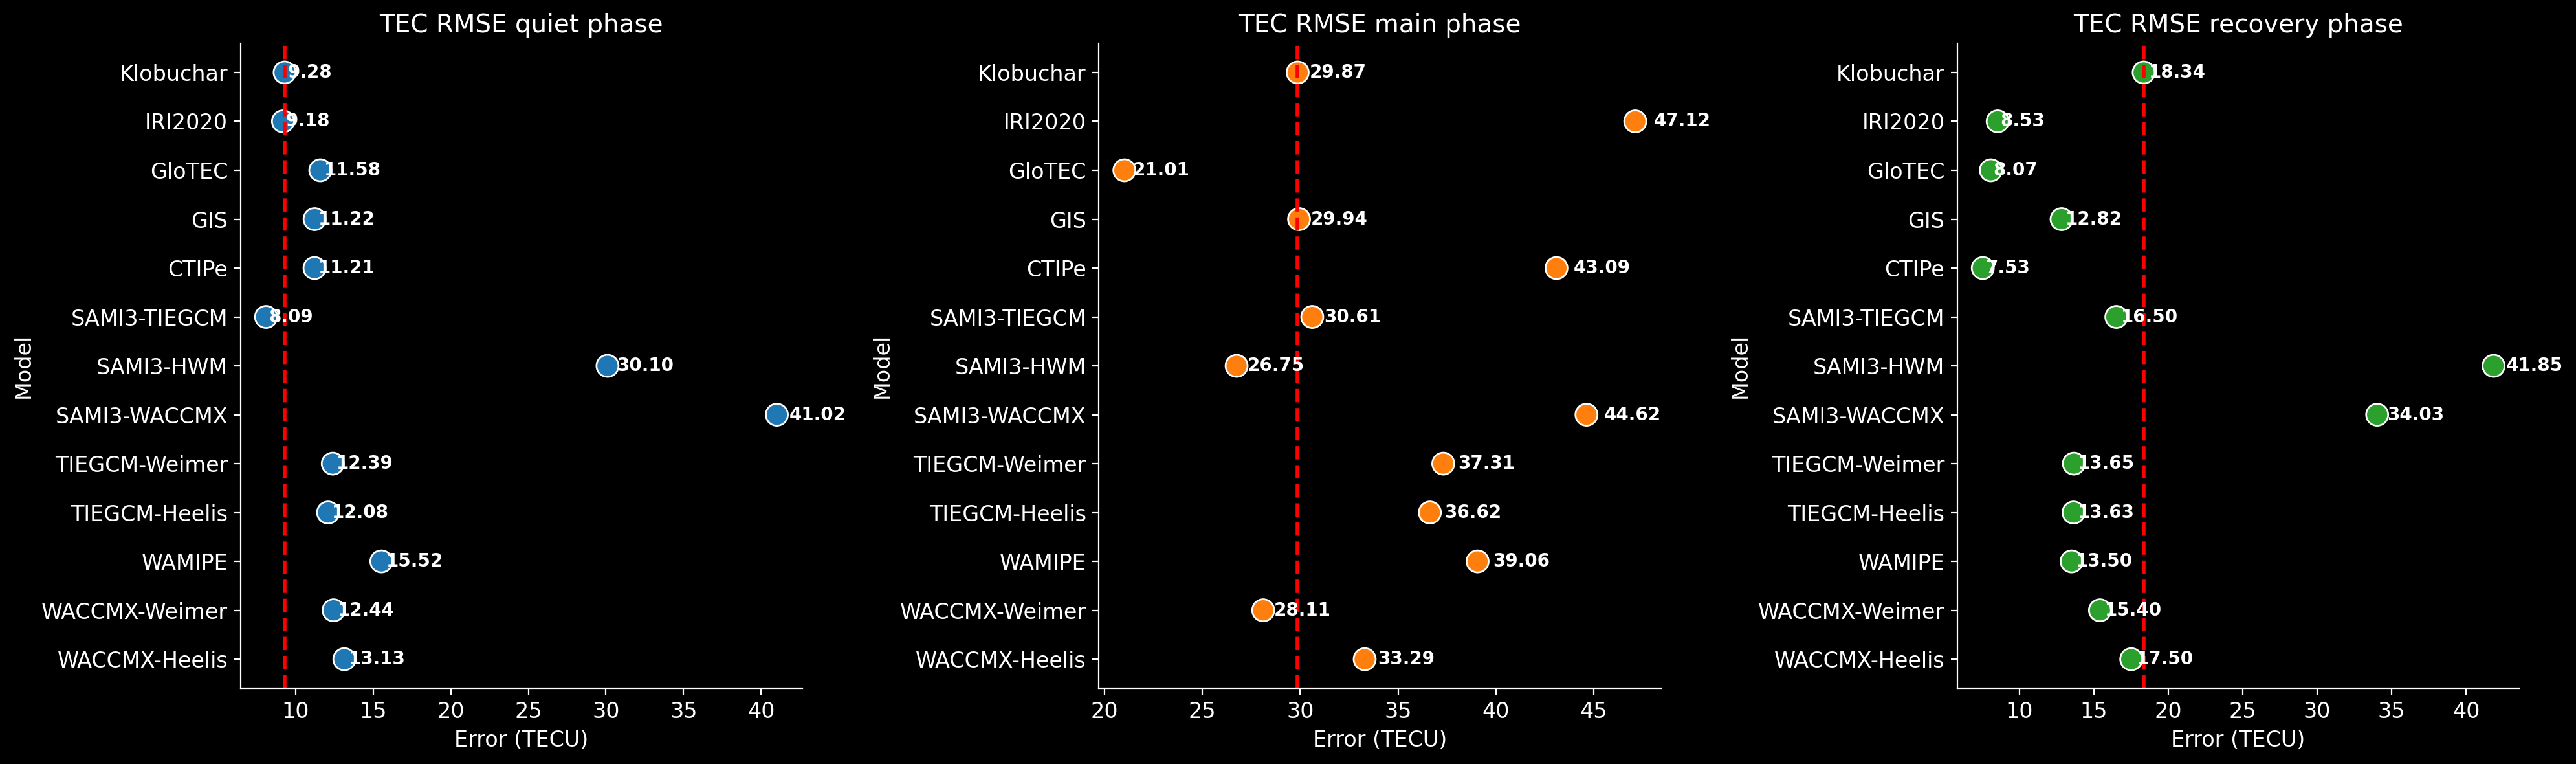

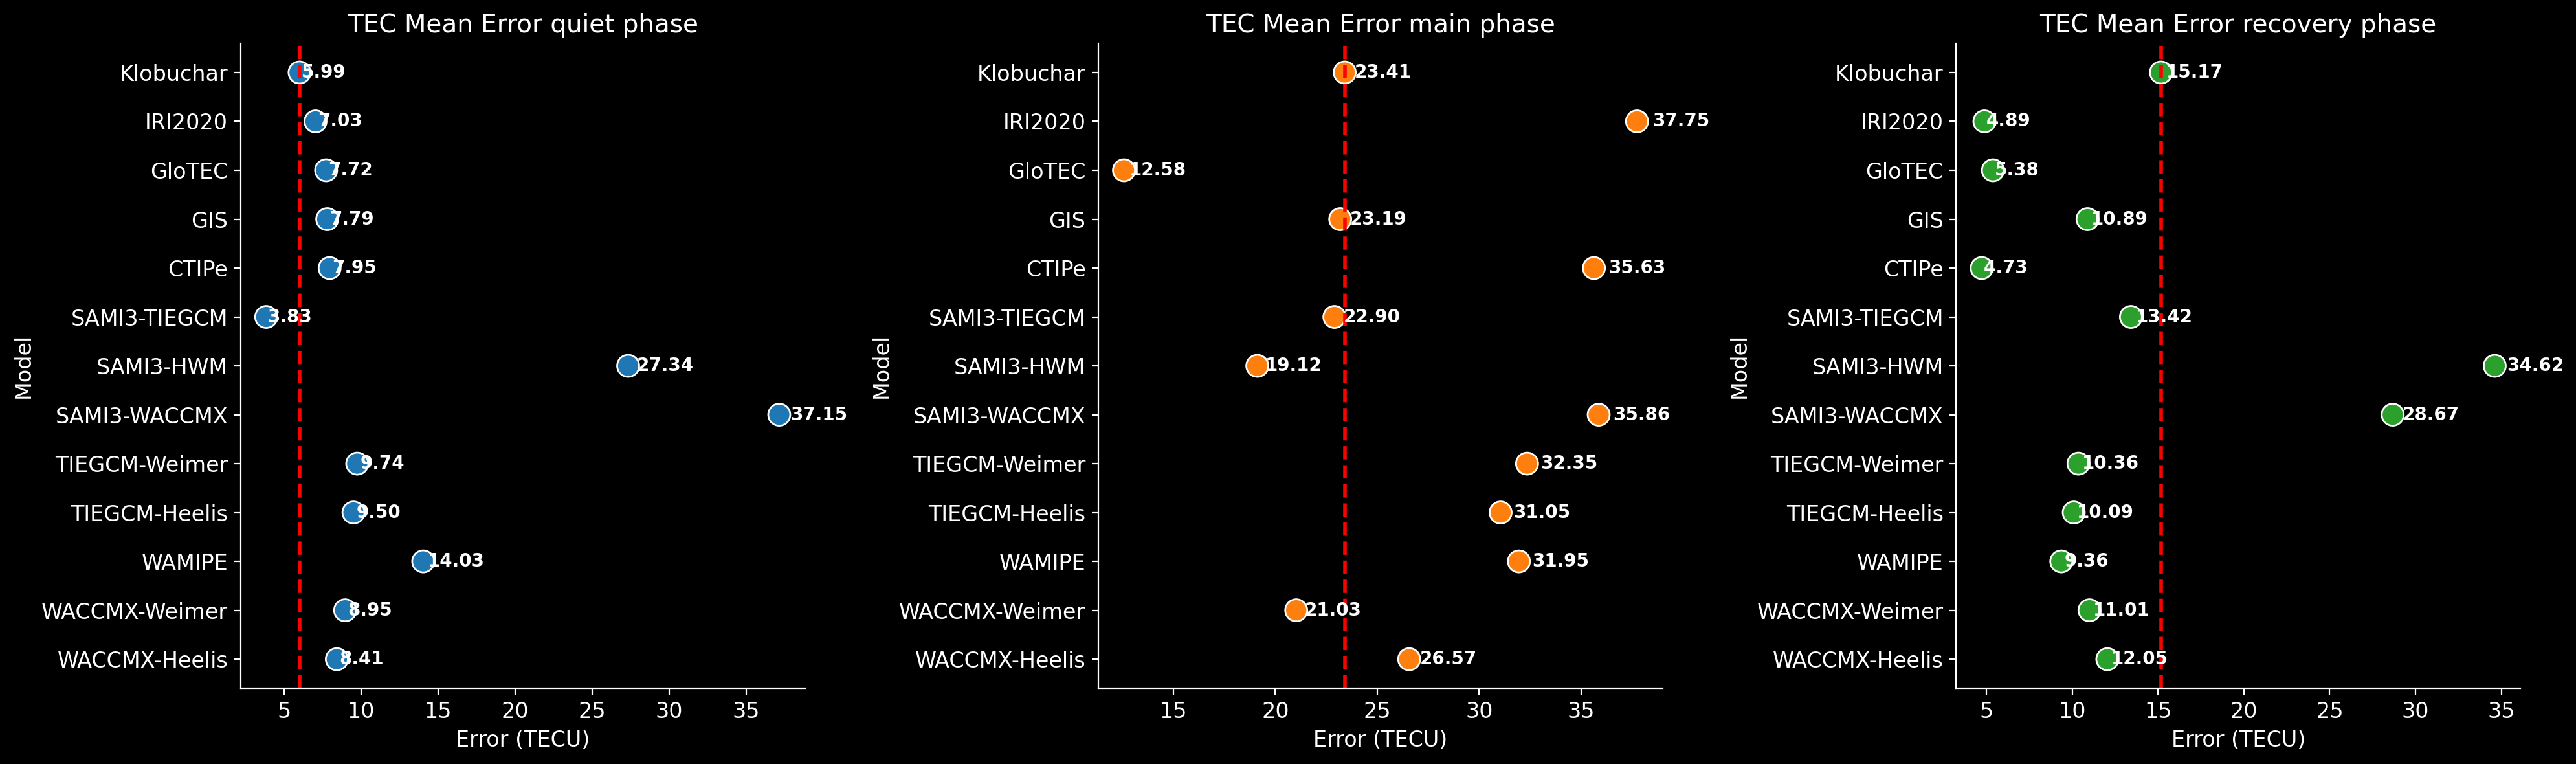

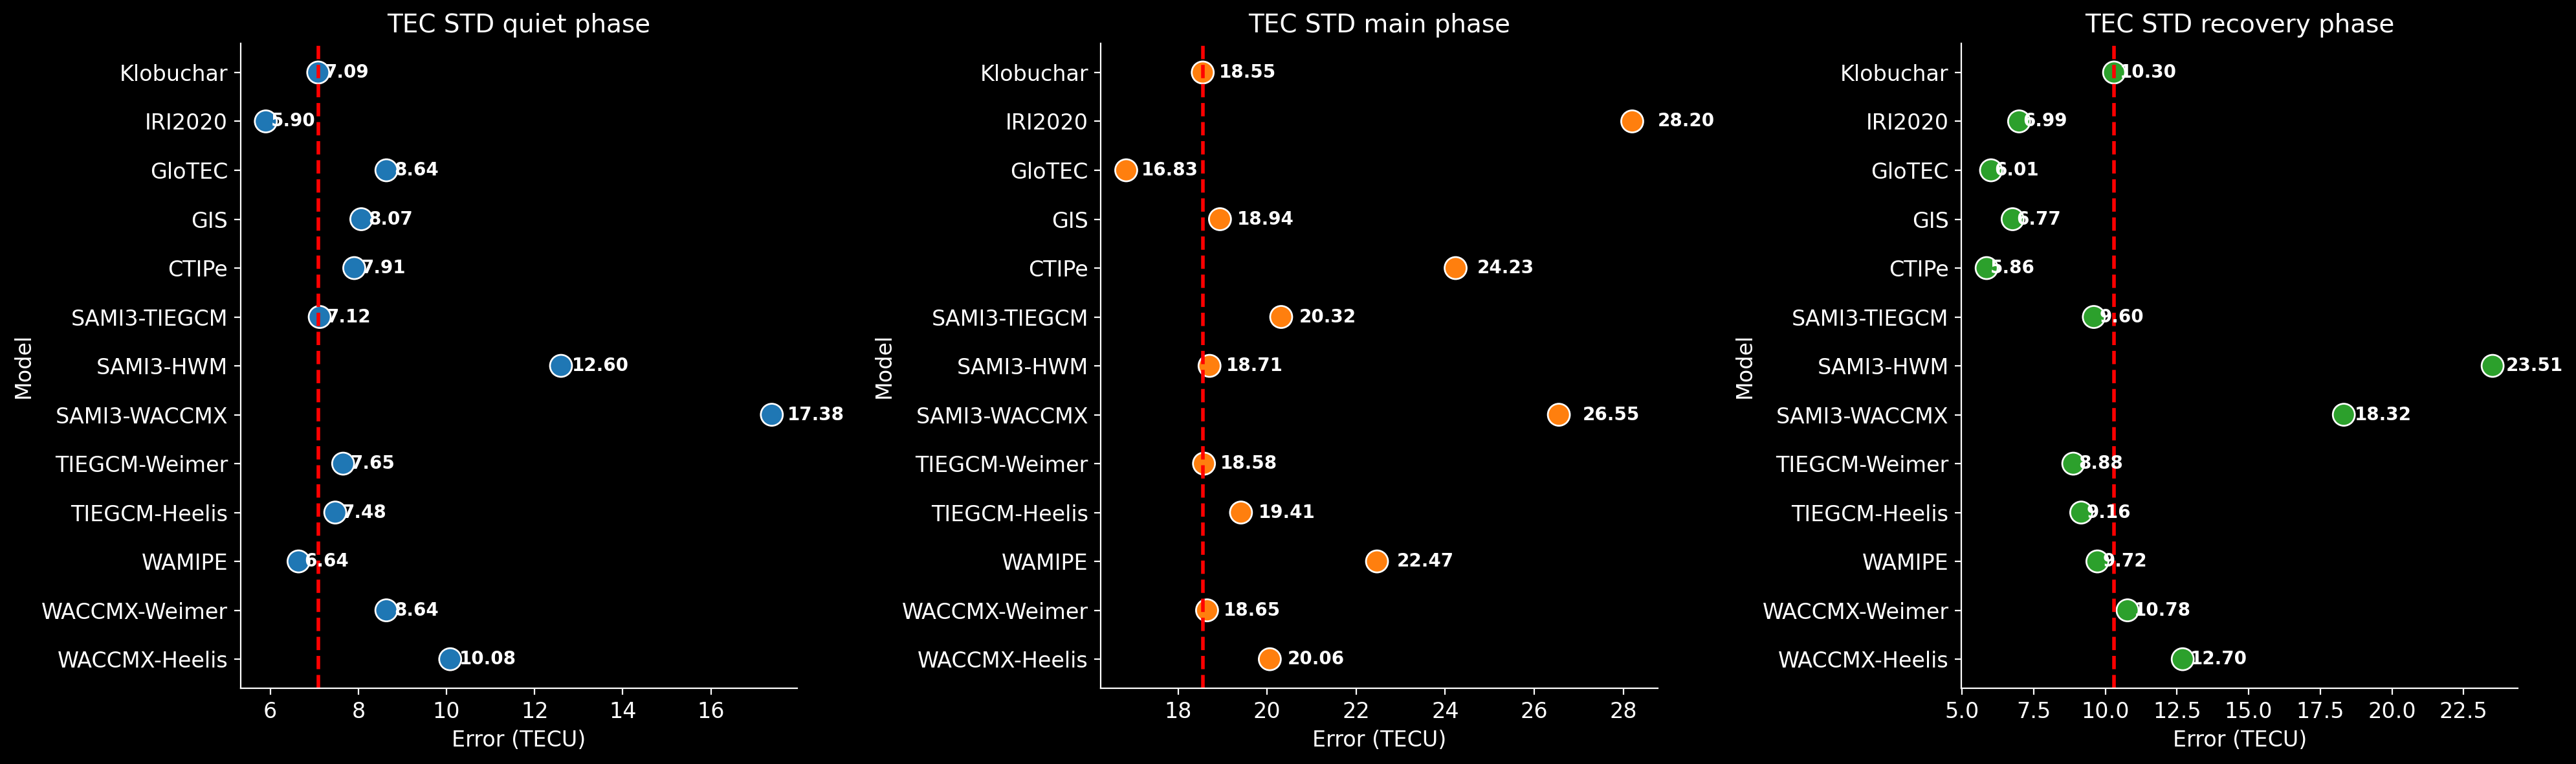

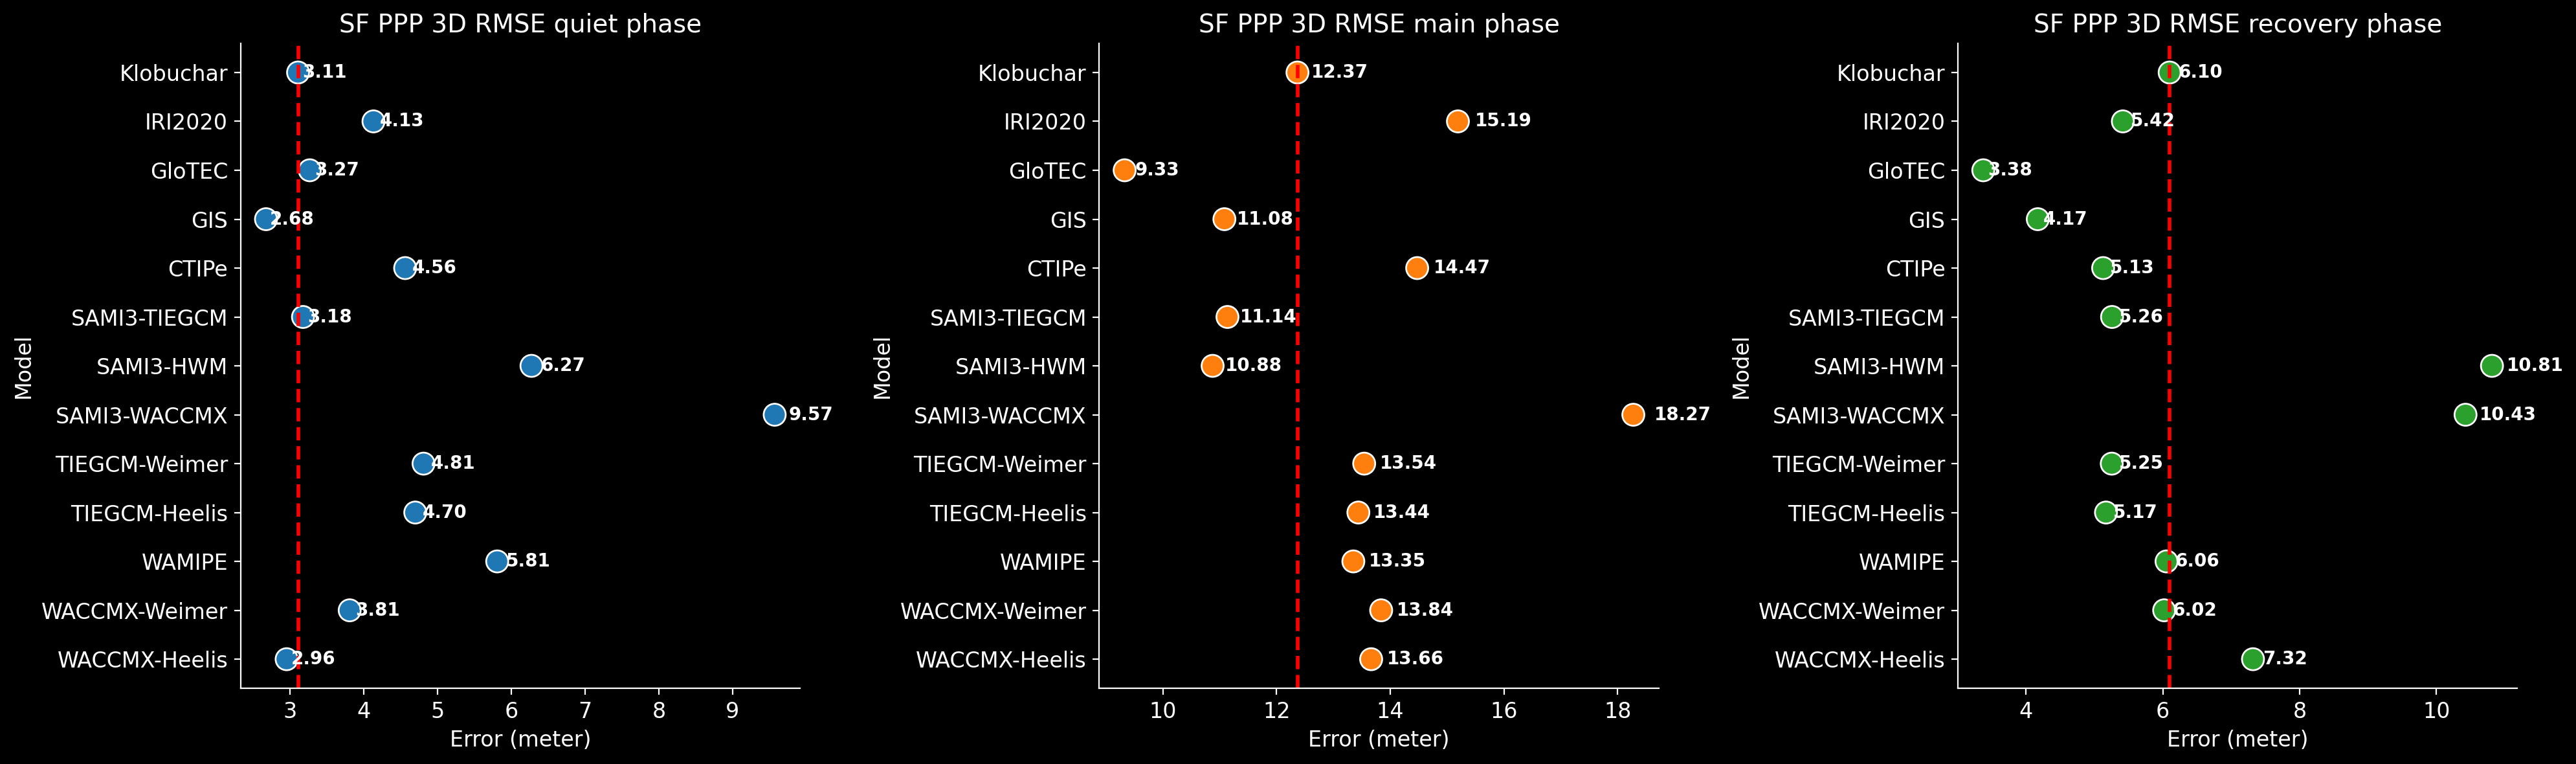

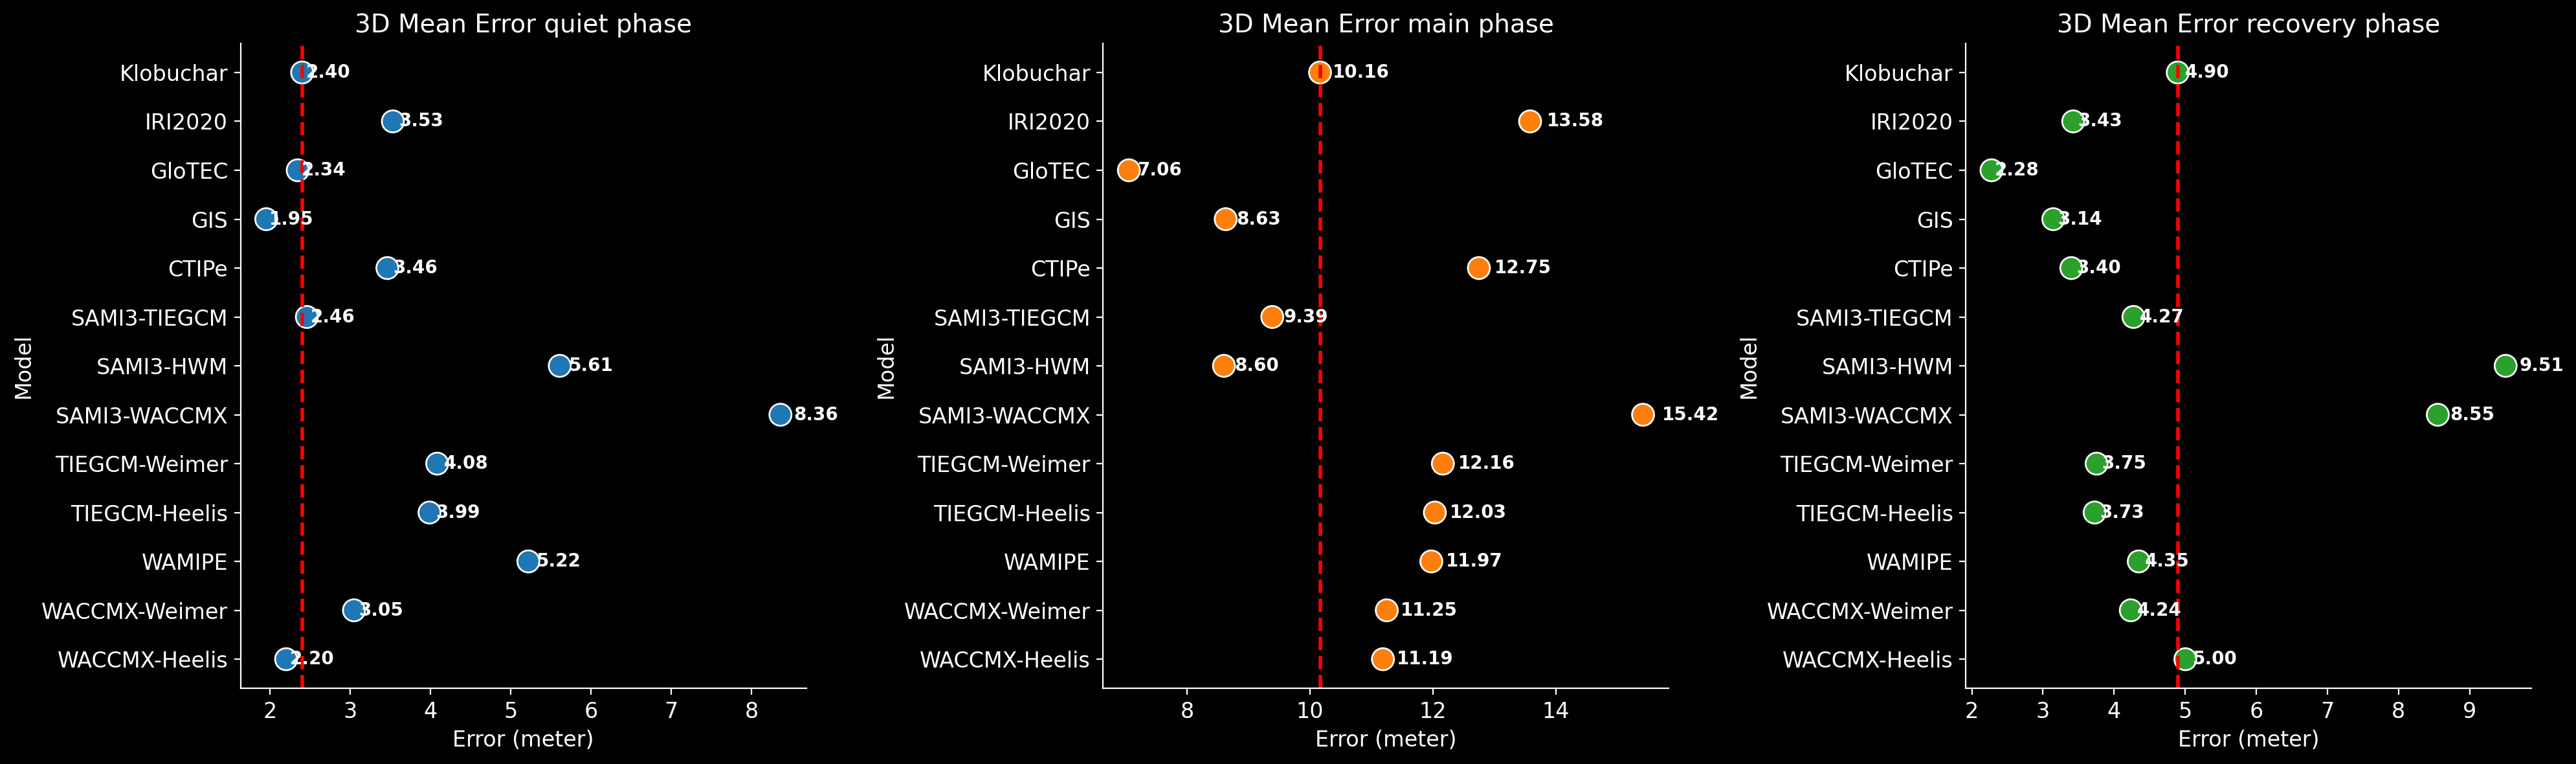

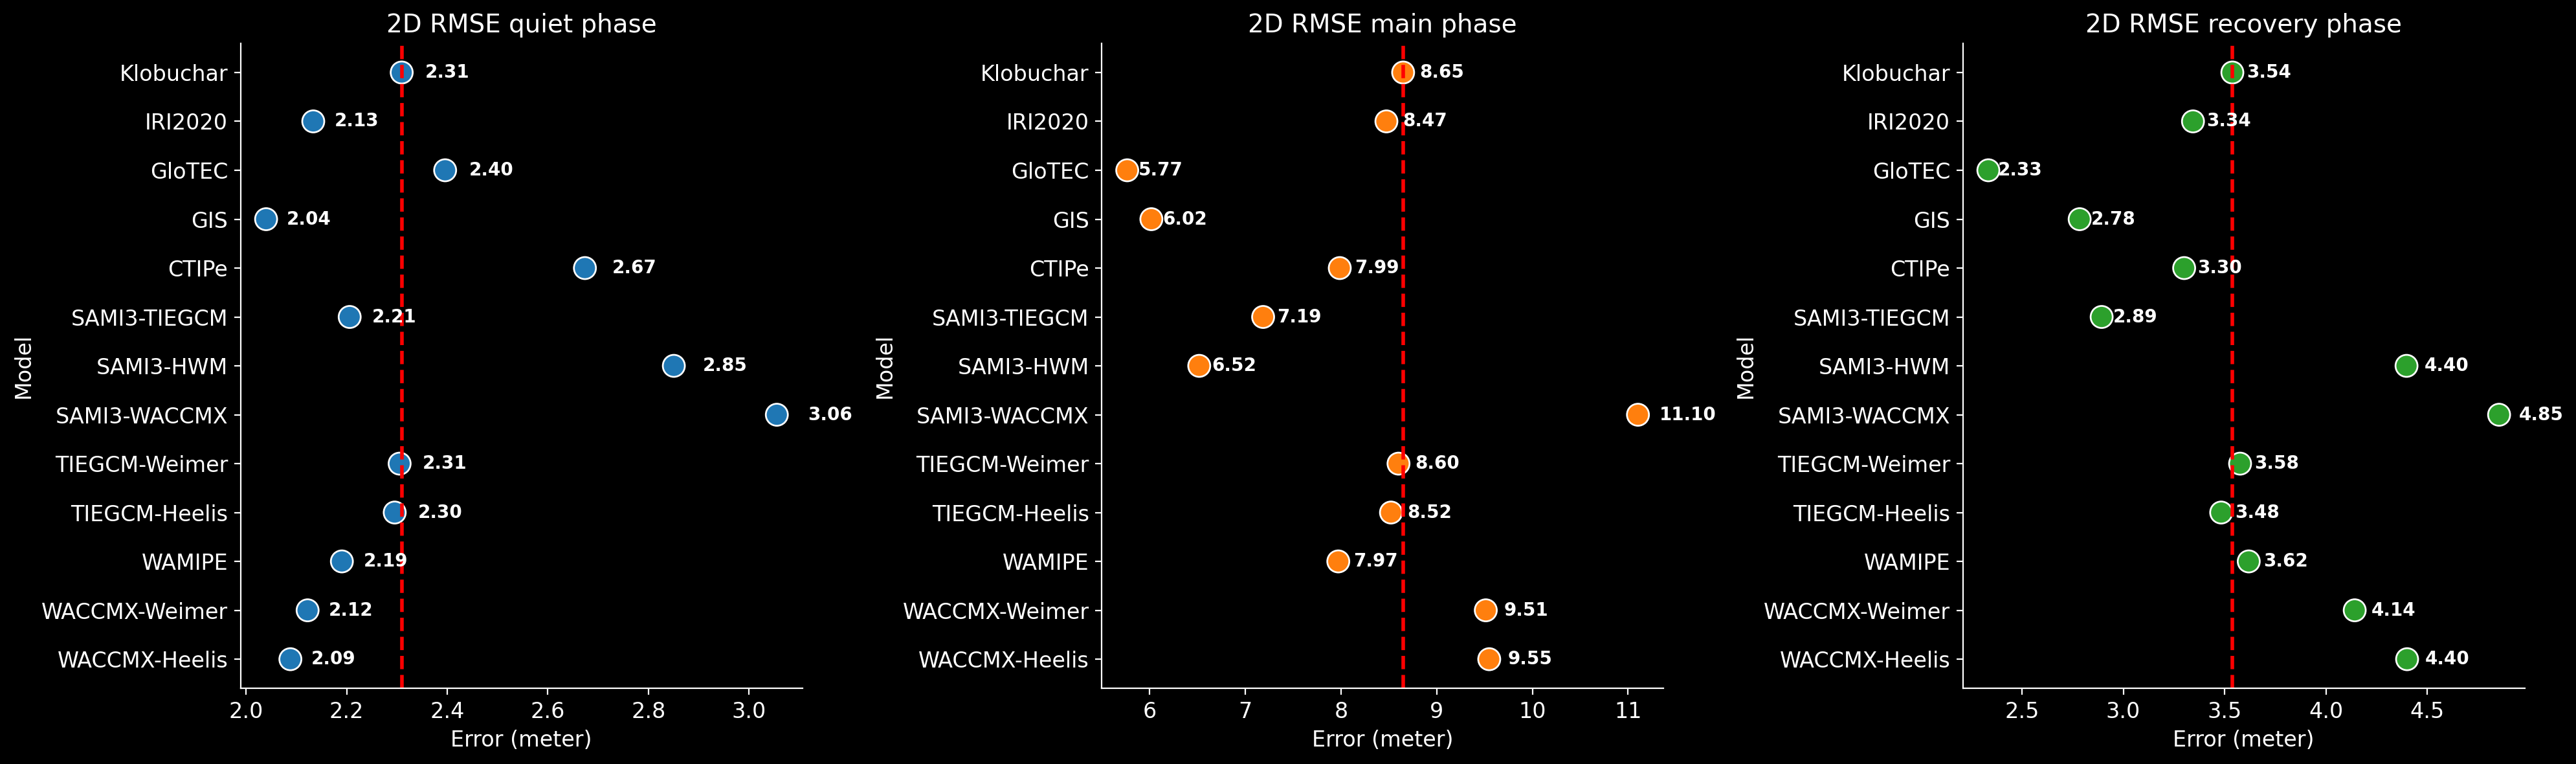

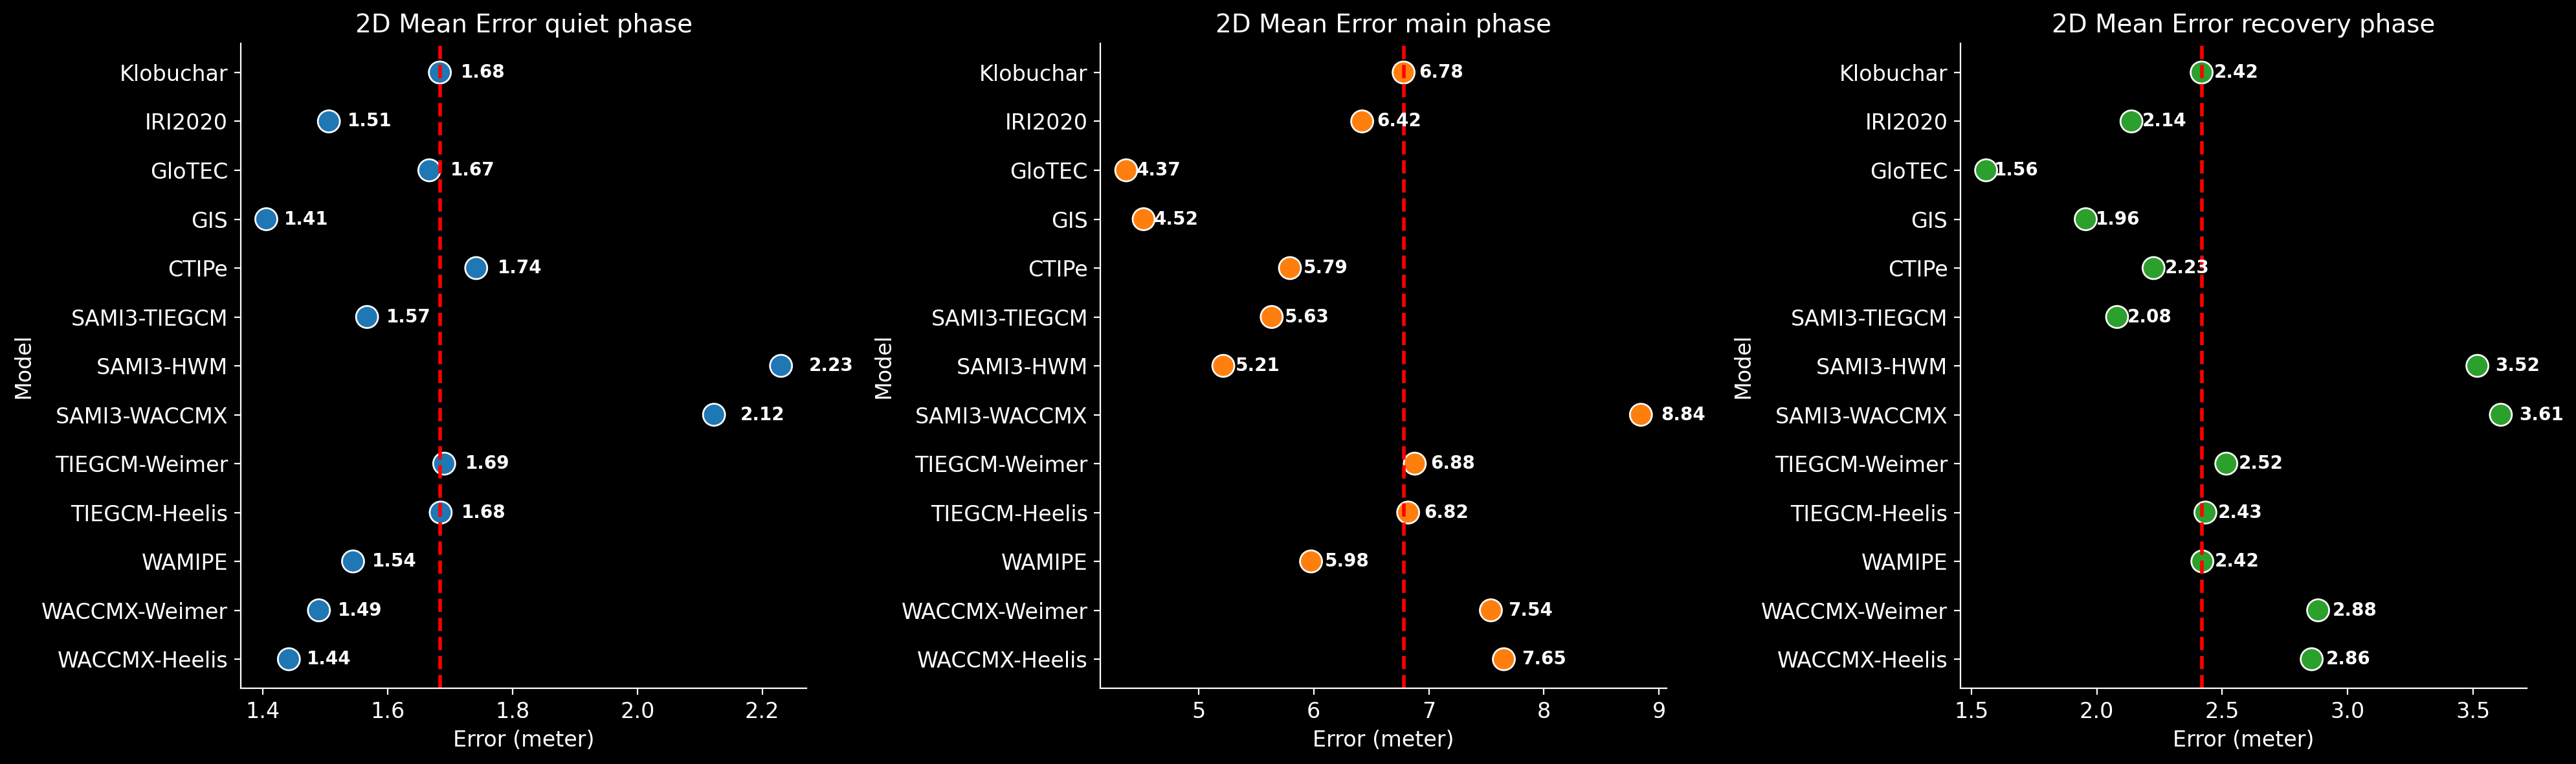

In [15]:

phases=['quiet phase', 'main phase', 'recovery phase']
var = ['TEC RMSE','TEC Mean Error','TEC STD','3D RMSE','3D Mean Error','2D RMSE','2D Mean Error']
#var = ['TEC RMSE']
unit=['TECU','TECU','TECU','meter','meter','meter','meter']

# Reshape the data for Seaborn (long format)

# Define custom colors for each phase
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, orange, green
#fig,(axs)=plt.subplots(1,3,dpi=200)
#fig.set_size_inches(20, 6)
#plt.style.use('dark_background')

#plt.figure(figsize=(6, 8))
for idx,var1 in enumerate(var):
    fig,(axs)=plt.subplots(1,3,dpi=200)
    fig.set_size_inches(20, 6)
    plt.style.use('dark_background')
    rms_long = combined_df[var1].reset_index().melt(id_vars='index', var_name='Phase', value_name=var1)
    rms_long.rename(columns={'index': 'Model'}, inplace=True)
    for idx0,phase in enumerate(phases):
        rms_long_filtered=rms_long[rms_long['Phase'] == phase]
        # Plot with Seaborn
        #plt.figure(figsize=(6, 8))
        #ax = sns.scatterplot(data=rms_long_filtered, x='Model', y='RMS Error', hue='Phase', palette=custom_colors)
        sns.scatterplot(data=rms_long_filtered, x=var1, y='Model', hue='Phase',
                        palette={phases[0]: custom_colors[0], phases[1]: custom_colors[1], phases[2]: custom_colors[2]},s=150, ax=axs[idx0])
        
        # Add text annotations on each dot
        for i, row in rms_long_filtered.iterrows():
            axs[idx0].text(row[var1]*1.02, row['Model'], f"{row[var1]:.2f}", 
                    ha='left', va='center', fontsize=10, color='w', weight='bold')
            if row['Model']=='Klobuchar':
                axs[idx0].axvline(x=row[var1], color='red', linestyle='--', linewidth=2, label='Klobuchar model')
        
        sns.despine()  # Removes the box
        axs[idx0].set_xlabel(f"Error ({unit[idx]})", fontsize=12)
        axs[idx0].set_ylabel("Model", fontsize=12)
        axs[idx0].tick_params(axis='y', labelsize=12)
        axs[idx0].tick_params(axis='x', labelsize=12) 
    
        #plt.yticks(rotation=45)
        #axs[idx1].legend(loc='upper left', bbox_to_anchor=(1, 1))  # Adjust this to place the legend outside the plot
        if idx==3:
            axs[idx0].set_title(f"SF PPP {var1} {phase}", fontsize=14)
        else:
            axs[idx0].set_title(f"{var1} {phase}", fontsize=14)
        axs[idx0].get_legend().remove()
    plt.tight_layout()
# Show plot
    plt.show()

